In [7]:
!pip3 install matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 6.6 MB/s  0:00:016.6 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 6.6 MB/s  0:00:00m 6.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━ 3/8 [fonttools]  WARNING: The scripts fonttools, pyftmerge, pyftsubset and ttx are installed in '/Users/kavishkakalhara/Library/Python/3.9/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [seaborn]━━━ 6/8 [matplotlib]


In [4]:
import pandas as pd
import numpy as np
import os
import torch
import torch.nn as nn
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve

# ==========================================
# 1. DATA LOADING (From your original script)
# ==========================================
def load_and_clean_data(data_path='./datasets/', samples_per_file=10000):
    files = {
        'b5': 'benign_samples_5sec.csv', 'b10': 'benign_samples_10sec.csv',
        'a5': 'attack_samples_5sec.csv', 'a10': 'attack_samples_10sec.csv'
    }
    dfs = []
    for key, fname in files.items():
        path = os.path.join(data_path, fname)
        if not os.path.exists(path): continue
        temp_df = pd.read_csv(path)
        temp_df = temp_df.sample(n=min(samples_per_file, len(temp_df)), random_state=42)
        temp_df["label"] = 1 if key.startswith("a") else 0
        dfs.append(temp_df)

    full_df = pd.concat(dfs, ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
    full_df = full_df.loc[:, (full_df != full_df.iloc[0]).any()] # Remove zero variance
    
    for col in full_df.select_dtypes(include=['object', 'category']).columns:
        if col != "label":
            full_df[col] = full_df[col].astype("category").cat.codes
            
    return full_df

# ==========================================
# 2. MODELS & ENSEMBLE CLASS
# ==========================================
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(LSTMAutoencoder, self).__init__()
        self.encoder = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.decoder = nn.LSTM(hidden_dim, input_dim, batch_first=True)
        
    def forward(self, x):
        _, (h_n, _) = self.encoder(x)
        h_n = h_n.repeat(x.size(1), 1, 1).transpose(0, 1)
        out, _ = self.decoder(h_n)
        return out

class IoTEnsembleDetector:
    def __init__(self, input_dim, lstm_hidden=32):
        self.input_dim = input_dim
        self.lstm = LSTMAutoencoder(input_dim, lstm_hidden)
        self.iso_forest = IsolationForest(n_estimators=200, random_state=42)
        self.scaler = RobustScaler()
        
    def prepare_sequences(self, data, window_size=5):
        sequences = []
        for i in range(len(data) - window_size + 1):
            sequences.append(data[i:i + window_size])
        return np.array(sequences)

    def train_models(self, X_train_benign):
        # Scale
        X_scaled = self.scaler.fit_transform(X_train_benign)
        
        # Train Isolation Forest
        print("Training Isolation Forest...")
        self.iso_forest.fit(X_scaled)
        
        # Train LSTM
        print("Training LSTM Autoencoder...")
        X_seq = torch.FloatTensor(self.prepare_sequences(X_scaled))
        optimizer = torch.optim.Adam(self.lstm.parameters(), lr=0.01)
        criterion = nn.MSELoss()
        
        for epoch in range(15):
            self.lstm.train()
            optimizer.zero_grad()
            output = self.lstm(X_seq)
            loss = criterion(output, X_seq)
            loss.backward()
            optimizer.step()
            if epoch % 5 == 0: print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

    def get_fused_scores(self, X_test_raw, w_lstm=0.6, w_if=0.4):
        X_scaled = self.scaler.transform(X_test_raw)
        
        # IF Score (Negated so high = anomaly)
        if_scores = -self.iso_forest.decision_function(X_scaled)
        
        # LSTM Score
        self.lstm.eval()
        with torch.no_grad():
            X_seq = torch.FloatTensor(self.prepare_sequences(X_scaled))
            reconstructed = self.lstm(X_seq)
            lstm_errors = torch.mean((X_seq - reconstructed)**2, dim=[1, 2]).numpy()
        
        # Normalize
        if_norm = (if_scores - if_scores.min()) / (if_scores.max() - if_scores.min() + 1e-9)
        lstm_norm = (lstm_errors - lstm_errors.min()) / (lstm_errors.max() - lstm_errors.min() + 1e-9)
        
        # Align indices (pad the beginning of LSTM scores due to windowing)
        pad = np.zeros(len(if_norm) - len(lstm_norm))
        lstm_norm = np.concatenate([pad, lstm_norm])
        
        return (w_lstm * lstm_norm) + (w_if * if_norm)

# ==========================================
# 3. MAIN EXECUTION FLOW
# ==========================================
# A. Load data
df = load_and_clean_data()
X = df.drop("label", axis=1).fillna(0)
y = df["label"]

# B. Split (Train on Benign only)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_train_benign = X_train[y_train == 0].values

# C. Initialize and Train
detector = IoTEnsembleDetector(input_dim=X.shape[1])
detector.train_models(X_train_benign)

# D. Evaluate
fused_scores = detector.get_fused_scores(X_test.values)

# Find optimal threshold using Precision-Recall
prec, rec, thres = precision_recall_curve(y_test, fused_scores)
f1 = 2 * (prec * rec) / (prec + rec + 1e-9)
best_threshold = thres[np.argmax(f1)]

y_pred = (fused_scores > best_threshold).astype(int)

print("\n--- FINAL ENSEMBLE REPORT ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, fused_scores):.4f}")

Training Isolation Forest...
Training LSTM Autoencoder...
Epoch 0, Loss: 6131057.500000
Epoch 5, Loss: 6130946.000000
Epoch 10, Loss: 6130921.500000

--- FINAL ENSEMBLE REPORT ---
              precision    recall  f1-score   support

           0       0.86      0.89      0.88      6000
           1       0.89      0.85      0.87      6000

    accuracy                           0.87     12000
   macro avg       0.87      0.87      0.87     12000
weighted avg       0.87      0.87      0.87     12000

ROC-AUC: 0.9104


Matplotlib is building the font cache; this may take a moment.


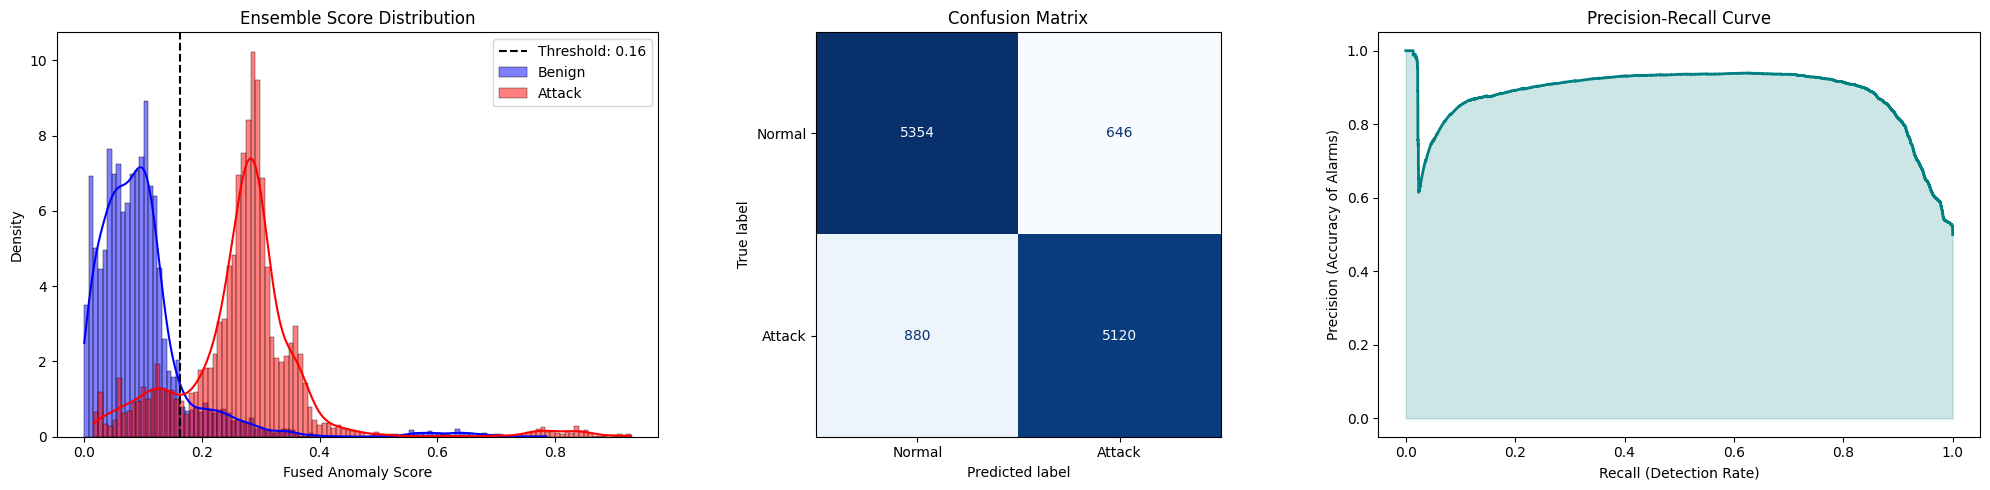

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_ensemble_performance(y_true, fused_scores, y_pred, best_threshold):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    
    # 1. Score Distribution (Separation)
    sns.histplot(fused_scores[y_true == 0], color="blue", label="Benign", kde=True, ax=axes[0], stat="density")
    sns.histplot(fused_scores[y_true == 1], color="red", label="Attack", kde=True, ax=axes[0], stat="density")
    axes[0].axvline(best_threshold, color='black', linestyle='--', label=f'Threshold: {best_threshold:.2f}')
    axes[0].set_title("Ensemble Score Distribution")
    axes[0].set_xlabel("Fused Anomaly Score")
    axes[0].legend()

    # 2. Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Attack"])
    disp.plot(ax=axes[1], cmap='Blues', colorbar=False)
    axes[1].set_title("Confusion Matrix")

    # 3. Precision-Recall Curve
    from sklearn.metrics import precision_recall_curve
    prec, rec, _ = precision_recall_curve(y_true, fused_scores)
    axes[2].plot(rec, prec, color='teal', lw=2)
    axes[2].fill_between(rec, prec, alpha=0.2, color='teal')
    axes[2].set_title("Precision-Recall Curve")
    axes[2].set_xlabel("Recall (Detection Rate)")
    axes[2].set_ylabel("Precision (Accuracy of Alarms)")

    plt.tight_layout()
    plt.show()

# Usage (Call this at the very end of your script):
plot_ensemble_performance(y_test, fused_scores, y_pred, best_threshold)

In [9]:
def plot_model_correlation(if_scores, lstm_scores, y_true):
    plt.figure(figsize=(8, 6))
    # Standardize for plotting
    if_norm = (if_scores - if_scores.min()) / (if_scores.max() - if_scores.min())
    lstm_norm = (lstm_scores - lstm_scores.min()) / (lstm_scores.max() - lstm_scores.min())
    
    sns.scatterplot(x=if_norm, y=lstm_norm, hue=y_true, palette=['blue', 'red'], alpha=0.5)
    plt.title("LSTM vs. Isolation Forest Score Correlation")
    plt.xlabel("Isolation Forest Score (Normalized)")
    plt.ylabel("LSTM Reconstruction Error (Normalized)")
    plt.legend(title="Label", labels=["Normal", "Attack"])
    plt.show()

Fitting Isolation Forest...
Fitting LSTM Autoencoder...
Epoch 0, Loss: 6131052.500000
Epoch 5, Loss: 6130947.000000
Epoch 10, Loss: 6130924.000000


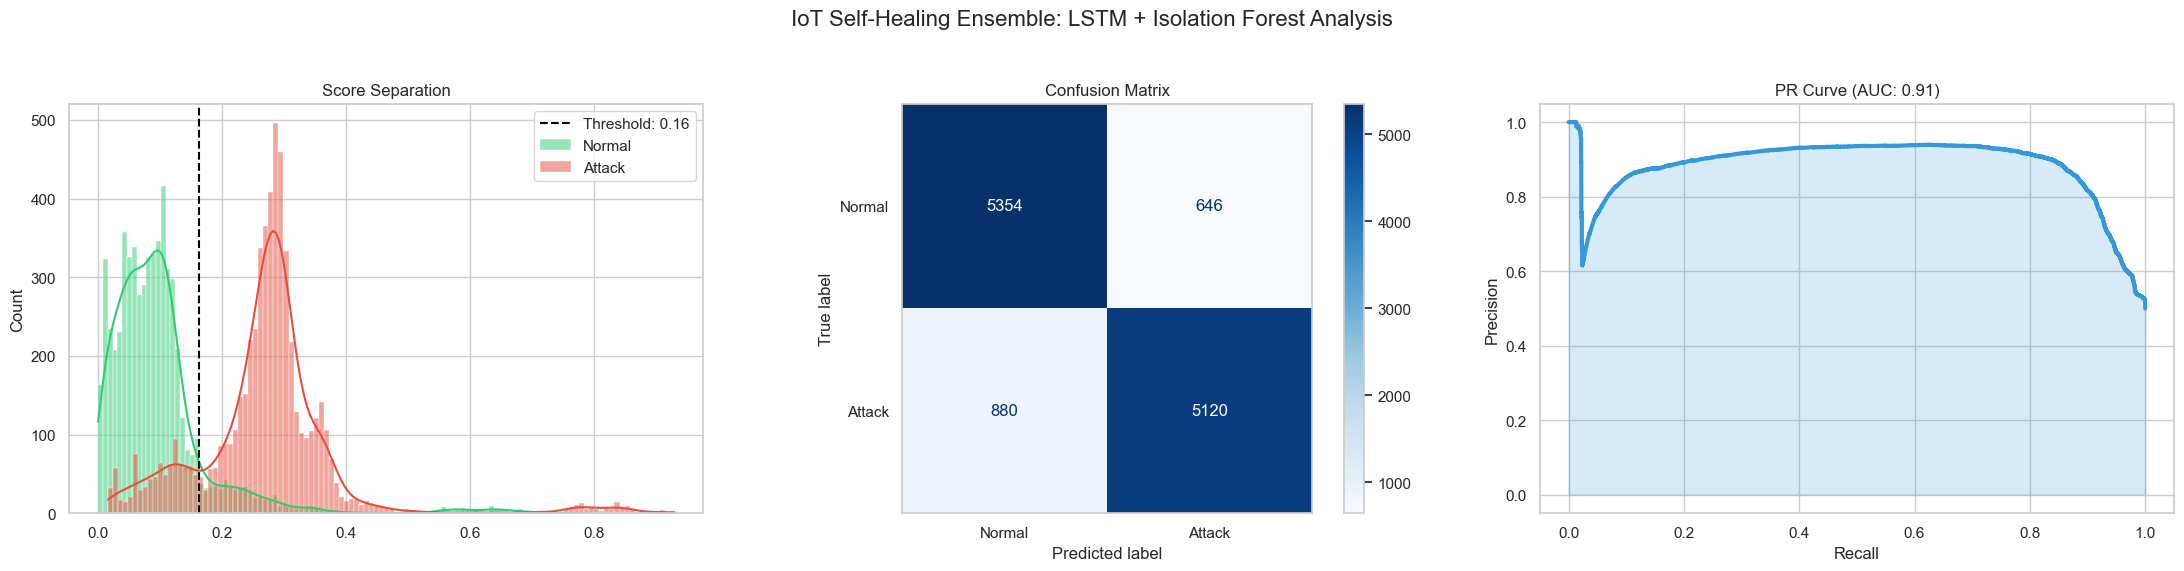

In [10]:
import pandas as pd
import numpy as np
import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score, precision_recall_curve, 
    confusion_matrix, ConfusionMatrixDisplay
)

# ==========================================
# 1. DATA LOADING & PREPROCESSING
# ==========================================
def load_and_clean_data(data_path='./datasets/', samples_per_file=10000):
    files = {
        'b5': 'benign_samples_5sec.csv', 'b10': 'benign_samples_10sec.csv',
        'a5': 'attack_samples_5sec.csv', 'a10': 'attack_samples_10sec.csv'
    }
    dfs = []
    for key, fname in files.items():
        path = os.path.join(data_path, fname)
        if not os.path.exists(path): continue
        temp_df = pd.read_csv(path)
        temp_df = temp_df.sample(n=min(samples_per_file, len(temp_df)), random_state=42)
        temp_df["label"] = 1 if key.startswith("a") else 0
        dfs.append(temp_df)

    full_df = pd.concat(dfs, ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
    full_df = full_df.loc[:, (full_df != full_df.iloc[0]).any()] # Zero variance
    for col in full_df.select_dtypes(include=['object', 'category']).columns:
        if col != "label":
            full_df[col] = full_df[col].astype("category").cat.codes
    return full_df

# ==========================================
# 2. ENSEMBLE CLASS
# ==========================================
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(LSTMAutoencoder, self).__init__()
        self.encoder = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.decoder = nn.LSTM(hidden_dim, input_dim, batch_first=True)
        
    def forward(self, x):
        _, (h_n, _) = self.encoder(x)
        h_n = h_n.repeat(x.size(1), 1, 1).transpose(0, 1)
        out, _ = self.decoder(h_n)
        return out

class IoTEnsembleDetector:
    def __init__(self, input_dim, lstm_hidden=32):
        self.lstm = LSTMAutoencoder(input_dim, lstm_hidden)
        self.iso_forest = IsolationForest(n_estimators=200, random_state=42)
        self.scaler = RobustScaler()
        
    def prepare_sequences(self, data, window_size=5):
        sequences = []
        for i in range(len(data) - window_size + 1):
            sequences.append(data[i:i + window_size])
        return np.array(sequences)

    def train_models(self, X_train_benign):
        X_scaled = self.scaler.fit_transform(X_train_benign)
        print("Fitting Isolation Forest...")
        self.iso_forest.fit(X_scaled)
        
        print("Fitting LSTM Autoencoder...")
        X_seq = torch.FloatTensor(self.prepare_sequences(X_scaled))
        optimizer = torch.optim.Adam(self.lstm.parameters(), lr=0.01)
        criterion = nn.MSELoss()
        for epoch in range(15):
            self.lstm.train()
            optimizer.zero_grad()
            output = self.lstm(X_seq)
            loss = criterion(output, X_seq)
            loss.backward()
            optimizer.step()
            if epoch % 5 == 0: print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

    def get_fused_scores(self, X_test_raw, w_lstm=0.6, w_if=0.4):
        X_scaled = self.scaler.transform(X_test_raw)
        if_scores = -self.iso_forest.decision_function(X_scaled)
        
        self.lstm.eval()
        with torch.no_grad():
            X_seq = torch.FloatTensor(self.prepare_sequences(X_scaled))
            reconstructed = self.lstm(X_seq)
            lstm_errors = torch.mean((X_seq - reconstructed)**2, dim=[1, 2]).numpy()
        
        if_norm = (if_scores - if_scores.min()) / (if_scores.max() - if_scores.min() + 1e-9)
        lstm_norm = (lstm_errors - lstm_errors.min()) / (lstm_errors.max() - lstm_errors.min() + 1e-9)
        pad = np.zeros(len(if_norm) - len(lstm_norm))
        lstm_norm = np.concatenate([pad, lstm_norm])
        return (w_lstm * lstm_norm) + (w_if * if_norm)

# ==========================================
# 3. RUN PIPELINE & VISUALIZE
# ==========================================
# Load and Split
df = load_and_clean_data()
X = df.drop("label", axis=1).fillna(0)
y = df["label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Train
detector = IoTEnsembleDetector(input_dim=X.shape[1])
detector.train_models(X_train[y_train == 0].values)

# Get Scores and Threshold
fused_scores = detector.get_fused_scores(X_test.values)
prec, rec, thres = precision_recall_curve(y_test, fused_scores)
f1 = 2 * (prec * rec) / (prec + rec + 1e-9)
best_threshold = thres[np.argmax(f1)]
y_pred = (fused_scores > best_threshold).astype(int)

# --- VISUALIZATION DASHBOARD ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# 1. Distribution
sns.histplot(fused_scores[y_test == 0], color="#2ecc71", label="Normal", kde=True, ax=axes[0])
sns.histplot(fused_scores[y_test == 1], color="#e74c3c", label="Attack", kde=True, ax=axes[0])
axes[0].axvline(best_threshold, color='black', linestyle='--', label=f'Threshold: {best_threshold:.2f}')
axes[0].set_title("Score Separation")
axes[0].legend()

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Attack"])
disp.plot(ax=axes[1], cmap='Blues', values_format='d')
axes[1].grid(False)
axes[1].set_title("Confusion Matrix")

# 3. Precision-Recall
axes[2].plot(rec, prec, color='#3498db', lw=3)
axes[2].fill_between(rec, prec, alpha=0.2, color='#3498db')
axes[2].set_title(f"PR Curve (AUC: {roc_auc_score(y_test, fused_scores):.2f})")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")

plt.suptitle("IoT Self-Healing Ensemble: LSTM + Isolation Forest Analysis", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [11]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve

# -----------------------------
# Reproducibility
# -----------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# -----------------------------
# Data loading
# -----------------------------
def load_and_clean_data(data_path='./datasets/', samples_per_file=15000):
    files = {
        'b5': 'benign_samples_5sec.csv', 'b10': 'benign_samples_10sec.csv',
        'a5': 'attack_samples_5sec.csv', 'a10': 'attack_samples_10sec.csv'
    }
    dfs = []
    for key, fname in files.items():
        path = os.path.join(data_path, fname)
        if not os.path.exists(path):
            continue
        temp_df = pd.read_csv(path)
        temp_df = temp_df.sample(n=min(samples_per_file, len(temp_df)), random_state=42)
        temp_df['label'] = 1 if key.startswith('a') else 0
        dfs.append(temp_df)

    if not dfs:
        raise FileNotFoundError('No dataset files found in ./datasets/')

    full_df = pd.concat(dfs, ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
    full_df = full_df.loc[:, (full_df != full_df.iloc[0]).any()]
    for col in full_df.select_dtypes(include=['object', 'category']).columns:
        if col != 'label':
            full_df[col] = full_df[col].astype('category').cat.codes
    return full_df

# -----------------------------
# Model definitions
# -----------------------------
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout=0.2):
        super().__init__()
        self.encoder = nn.LSTM(input_dim, hidden_dim, batch_first=True, dropout=dropout)
        self.decoder = nn.LSTM(hidden_dim, input_dim, batch_first=True, dropout=dropout)

    def forward(self, x):
        _, (h_n, _) = self.encoder(x)
        h_n = h_n.repeat(x.size(1), 1, 1).transpose(0, 1)
        out, _ = self.decoder(h_n)
        return out

class IoTEnsembleDetector:
    def __init__(self, input_dim, lstm_hidden=32, window_size=8, if_params=None):
        self.input_dim = input_dim
        self.window_size = window_size
        self.lstm = LSTMAutoencoder(input_dim, lstm_hidden)
        if_params = if_params or {'n_estimators': 300, 'max_samples': 0.8, 'max_features': 0.8, 'contamination': 0.05}
        self.iso_forest = IsolationForest(random_state=42, **if_params)
        self.scaler = RobustScaler()

    def prepare_sequences(self, data):
        sequences = []
        for i in range(len(data) - self.window_size + 1):
            sequences.append(data[i:i + self.window_size])
        return np.array(sequences)

    def train_models(self, X_train_benign, max_epochs=30, patience=5, batch_size=256, lr=0.001):
        X_scaled = self.scaler.fit_transform(X_train_benign)
        self.iso_forest.fit(X_scaled)

        X_train, X_val = train_test_split(X_scaled, test_size=0.2, random_state=42)
        X_train_seq = torch.FloatTensor(self.prepare_sequences(X_train))
        X_val_seq = torch.FloatTensor(self.prepare_sequences(X_val))

        optimizer = torch.optim.Adam(self.lstm.parameters(), lr=lr)
        criterion = nn.MSELoss()
        best_val = float('inf')
        bad_epochs = 0

        for epoch in range(max_epochs):
            self.lstm.train()
            perm = torch.randperm(X_train_seq.size(0))
            epoch_loss = 0.0
            for i in range(0, len(perm), batch_size):
                idx = perm[i:i + batch_size]
                batch = X_train_seq[idx]
                optimizer.zero_grad()
                output = self.lstm(batch)
                loss = criterion(output, batch)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()
            self.lstm.eval()
            with torch.no_grad():
                val_out = self.lstm(X_val_seq)
                val_loss = criterion(val_out, X_val_seq).item()
            if val_loss < best_val - 1e-5:
                best_val = val_loss
                bad_epochs = 0
            else:
                bad_epochs += 1
            if bad_epochs >= patience:
                break

    def get_scores(self, X_raw):
        X_scaled = self.scaler.transform(X_raw)
        if_scores = -self.iso_forest.decision_function(X_scaled)
        self.lstm.eval()
        with torch.no_grad():
            X_seq = torch.FloatTensor(self.prepare_sequences(X_scaled))
            reconstructed = self.lstm(X_seq)
            lstm_errors = torch.mean((X_seq - reconstructed) ** 2, dim=[1, 2]).numpy()
        if_norm = (if_scores - if_scores.min()) / (if_scores.max() - if_scores.min() + 1e-9)
        lstm_norm = (lstm_errors - lstm_errors.min()) / (lstm_errors.max() - lstm_errors.min() + 1e-9)
        pad = np.zeros(len(if_norm) - len(lstm_norm))
        lstm_norm = np.concatenate([pad, lstm_norm])
        return if_norm, lstm_norm

    @staticmethod
    def fuse_scores(if_norm, lstm_norm, w_lstm=0.6):
        w_if = 1.0 - w_lstm
        return (w_lstm * lstm_norm) + (w_if * if_norm)

# -----------------------------
# Train/val/test split
# -----------------------------
df = load_and_clean_data()
X = df.drop('label', axis=1).fillna(0).values
y = df['label'].values
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
 )
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, stratify=y_train_full, random_state=42
 )

# -----------------------------
# Lightweight hyperparameter search
# -----------------------------
param_grid = [
    {'lstm_hidden': 24, 'window_size': 6, 'if_params': {'n_estimators': 200, 'max_samples': 0.9, 'max_features': 0.8, 'contamination': 0.05}},
    {'lstm_hidden': 32, 'window_size': 8, 'if_params': {'n_estimators': 300, 'max_samples': 0.8, 'max_features': 0.8, 'contamination': 0.05}},
    {'lstm_hidden': 48, 'window_size': 10, 'if_params': {'n_estimators': 300, 'max_samples': 0.8, 'max_features': 0.6, 'contamination': 0.05}},
 ]
weight_grid = [0.4, 0.5, 0.6, 0.7]

best = {'f1': -1}
for params in param_grid:
    detector = IoTEnsembleDetector(input_dim=X.shape[1], **params)
    detector.train_models(X_train[y_train == 0])
    if_norm, lstm_norm = detector.get_scores(X_val)
    for w in weight_grid:
        fused = detector.fuse_scores(if_norm, lstm_norm, w_lstm=w)
        prec, rec, thres = precision_recall_curve(y_val, fused)
        f1 = 2 * (prec * rec) / (prec + rec + 1e-9)
        best_idx = int(np.argmax(f1))
        best_f1 = float(f1[best_idx])
        if best_f1 > best['f1']:
            best = {
                'f1': best_f1,
                'threshold': float(thres[best_idx]) if best_idx < len(thres) else float(thres[-1]),
                'weight': w,
                'params': params,
                'detector': detector,
            }

# -----------------------------
# Final evaluation on test set
# -----------------------------
best_detector = best['detector']
if_norm_test, lstm_norm_test = best_detector.get_scores(X_test)
fused_test = best_detector.fuse_scores(if_norm_test, lstm_norm_test, w_lstm=best['weight'])
y_pred = (fused_test > best['threshold']).astype(int)

print('Best params:', best['params'])
print('Best LSTM weight:', best['weight'])
print('Best threshold:', f"{best['threshold']:.4f}")
print('\n--- FINAL ENSEMBLE REPORT ---')
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, fused_test):.4f}")

/Users/kavishkakalhara/Library/Python/3.9/lib/python/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(
/Users/kavishkakalhara/Library/Python/3.9/lib/python/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(
/Users/kavishkakalhara/Library/Python/3.9/lib/python/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


Best params: {'lstm_hidden': 32, 'window_size': 8, 'if_params': {'n_estimators': 300, 'max_samples': 0.8, 'max_features': 0.8, 'contamination': 0.05}}
Best LSTM weight: 0.4
Best threshold: 0.1680

--- FINAL ENSEMBLE REPORT ---
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      5736
           1       0.90      0.91      0.90      6000

    accuracy                           0.90     11736
   macro avg       0.90      0.90      0.90     11736
weighted avg       0.90      0.90      0.90     11736

ROC-AUC: 0.9532


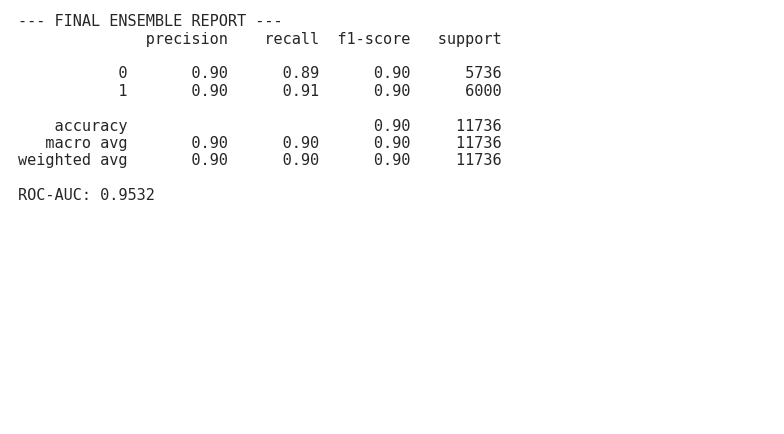

In [5]:
# Render the final report as a figure.
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt

report_text = classification_report(y_test, y_pred, digits=2)
roc_auc = roc_auc_score(y_test, fused_test)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.axis("off")

full_text = (
    "--- FINAL ENSEMBLE REPORT ---\n"
    + report_text
    + f"\nROC-AUC: {roc_auc:.4f}"
 )
ax.text(0.01, 0.99, full_text, va="top", ha="left", family="monospace", fontsize=11)
plt.tight_layout()
plt.show()

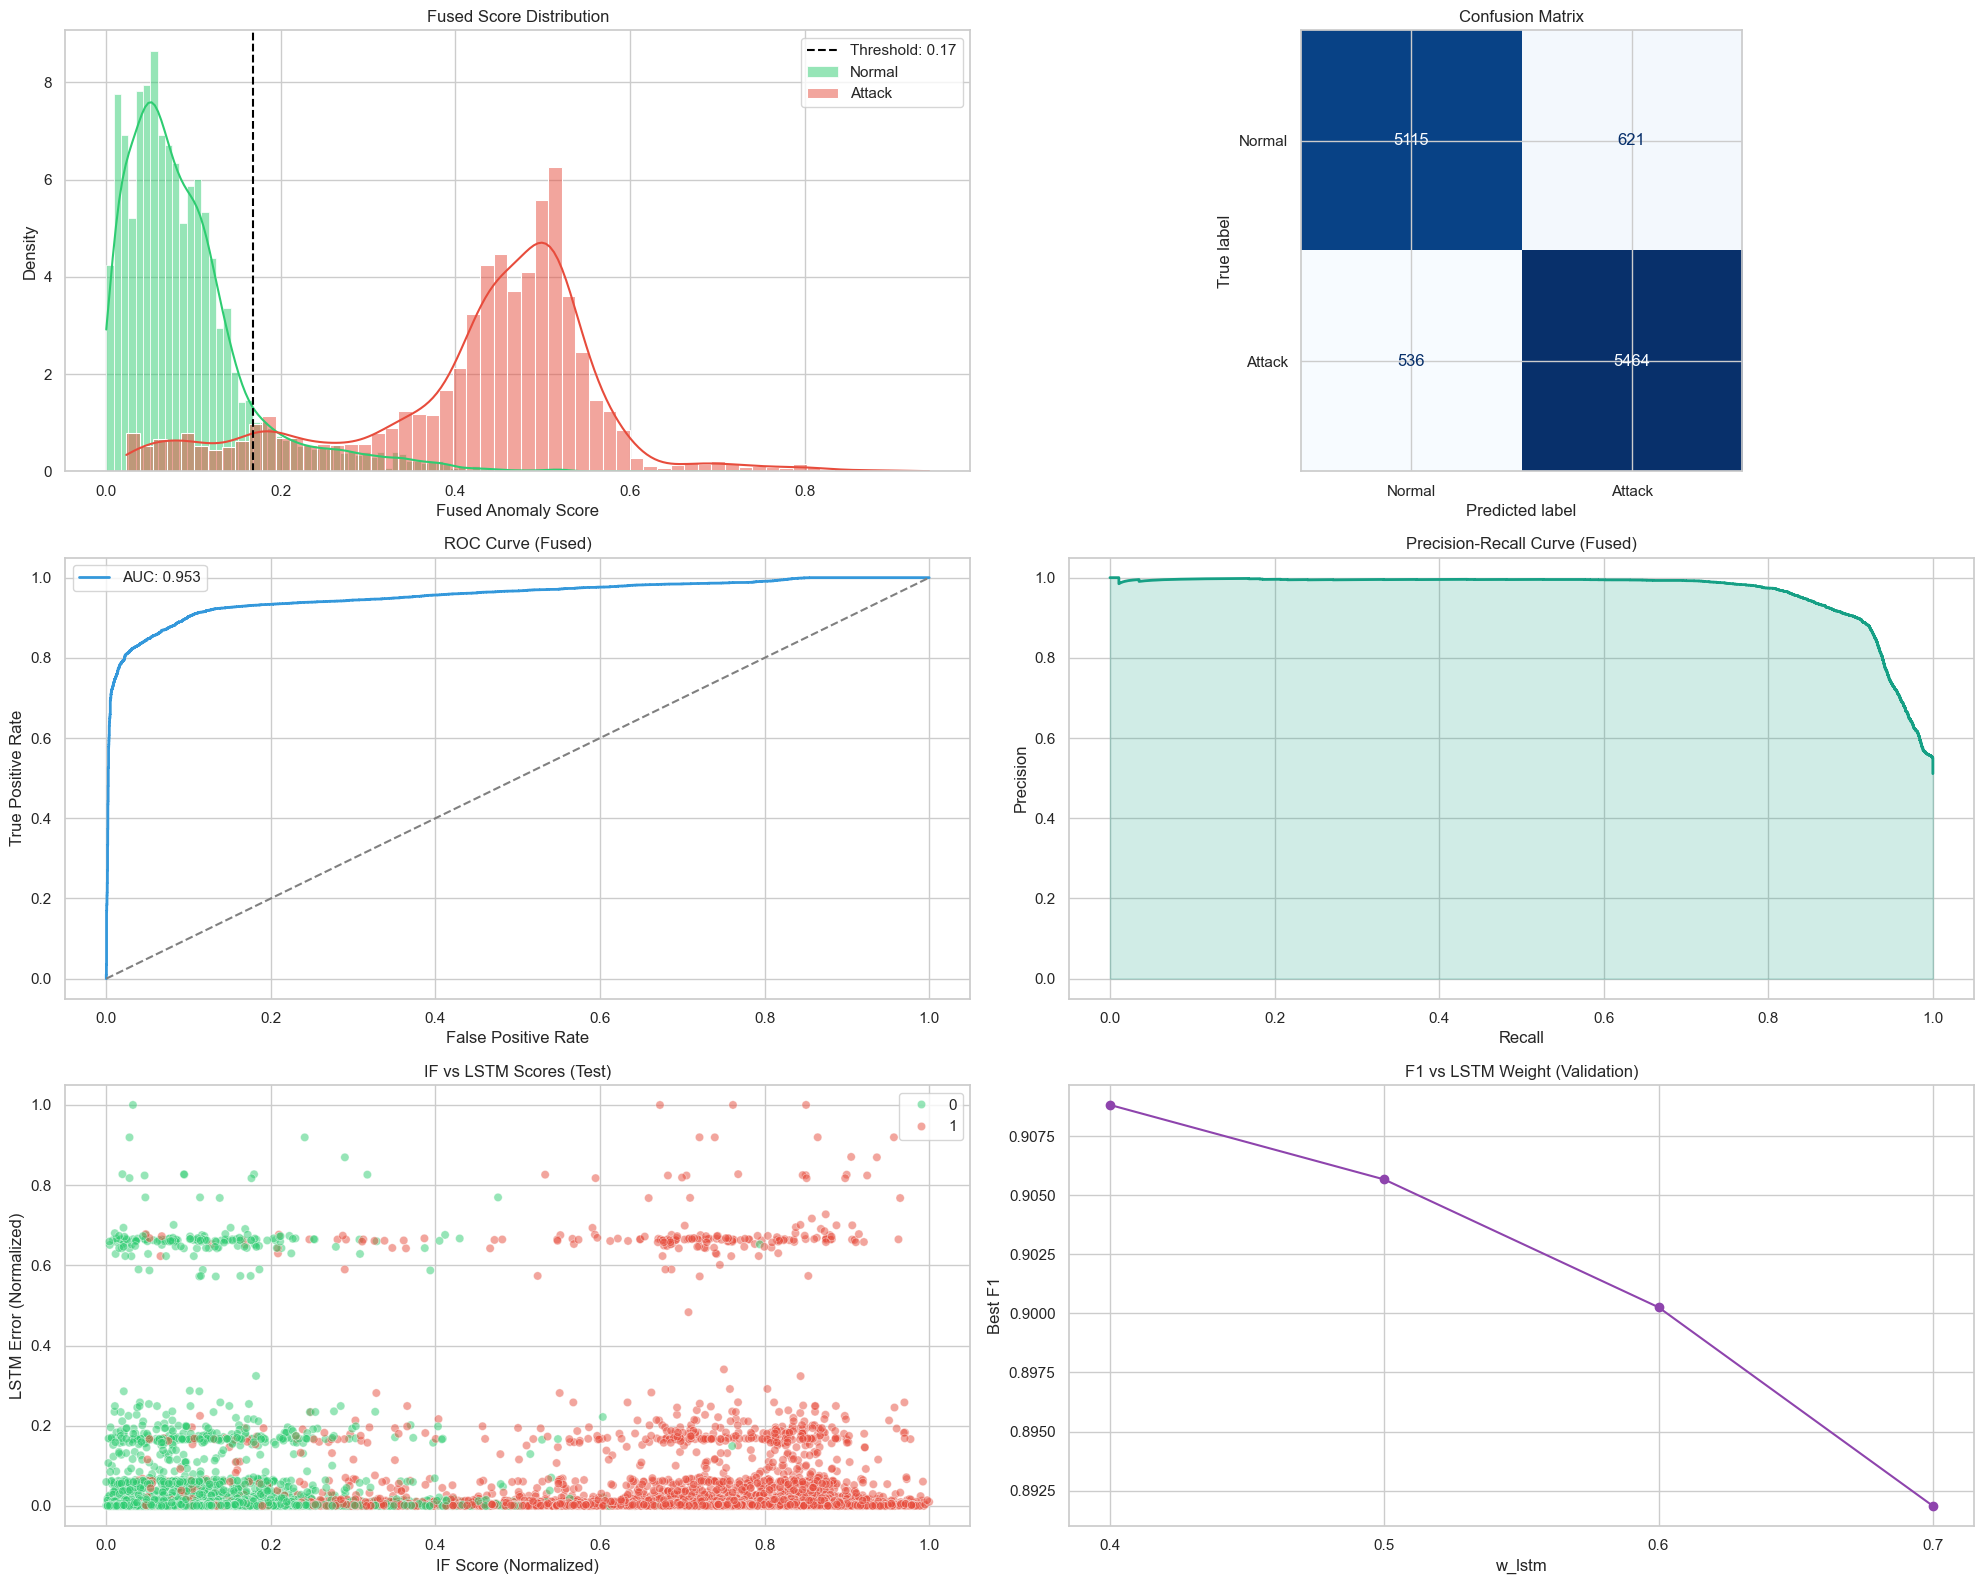

/var/folders/25/s5kmh86923q9llc_sj429pdr0000gn/T/ipykernel_21317/2922783777.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_df, x='Model', y='Best_F1', ax=axes[0], palette="viridis")
/var/folders/25/s5kmh86923q9llc_sj429pdr0000gn/T/ipykernel_21317/2922783777.py:118: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_df, x='Model', y='ROC_AUC', ax=axes[1], palette="magma")


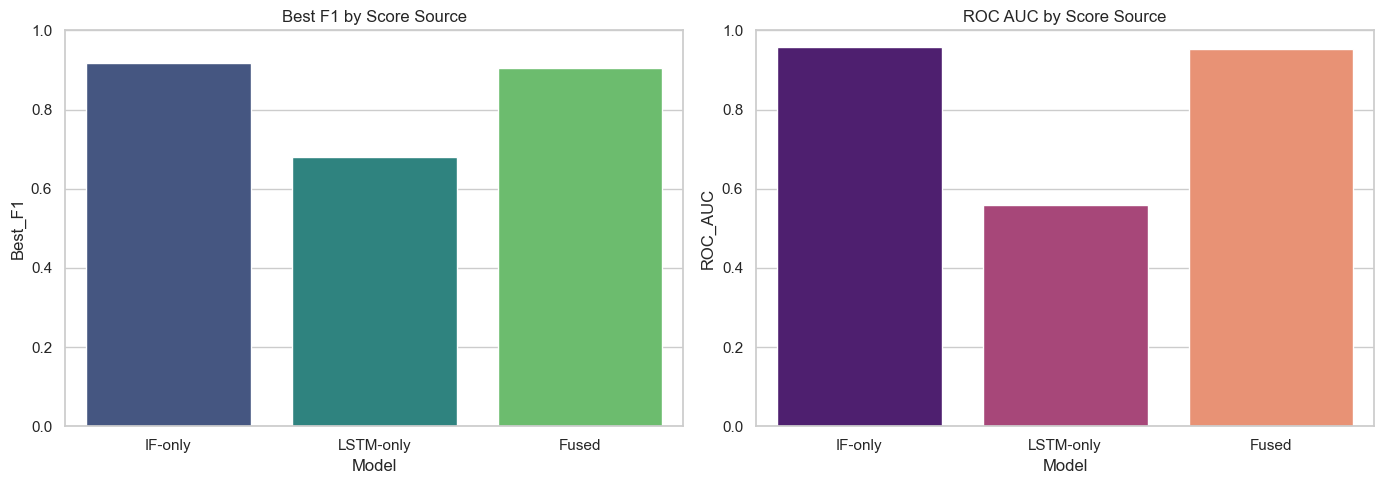

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve, f1_score
 )

sns.set_theme(style="whitegrid")

# -----------------------------
# Score components on test set
# -----------------------------
if_norm_test, lstm_norm_test = best_detector.get_scores(X_test)
fused_test = best_detector.fuse_scores(if_norm_test, lstm_norm_test, w_lstm=best['weight'])
y_pred = (fused_test > best['threshold']).astype(int)

# -----------------------------
# Comparison: IF-only vs LSTM-only vs Fused
# -----------------------------
score_sets = {
    'IF-only': if_norm_test,
    'LSTM-only': lstm_norm_test,
    'Fused': fused_test,
}
metric_rows = []
for name, scores in score_sets.items():
    pred = (scores > np.quantile(scores, 0.95)).astype(int) if name != 'Fused' else y_pred
    prec, rec, _ = precision_recall_curve(y_test, scores)
    f1 = np.max(2 * (prec * rec) / (prec + rec + 1e-9))
    fpr, tpr, _ = roc_curve(y_test, scores)
    metric_rows.append({
        'Model': name,
        'Best_F1': f1,
        'ROC_AUC': auc(fpr, tpr),
    })
metrics_df = pd.DataFrame(metric_rows)

# -----------------------------
# Weight sensitivity on validation data
# -----------------------------
if_norm_val, lstm_norm_val = best_detector.get_scores(X_val)
weight_perf = []
for w in weight_grid:
    fused_val = best_detector.fuse_scores(if_norm_val, lstm_norm_val, w_lstm=w)
    prec, rec, _ = precision_recall_curve(y_val, fused_val)
    f1 = np.max(2 * (prec * rec) / (prec + rec + 1e-9))
    weight_perf.append({'w_lstm': w, 'best_f1': f1})
weight_df = pd.DataFrame(weight_perf)

# -----------------------------
# Plots
# -----------------------------
fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(3, 2)

# 1) Score distribution
ax1 = fig.add_subplot(gs[0, 0])
sns.histplot(fused_test[y_test == 0], color="#2ecc71", label="Normal", kde=True, ax=ax1, stat="density")
sns.histplot(fused_test[y_test == 1], color="#e74c3c", label="Attack", kde=True, ax=ax1, stat="density")
ax1.axvline(best['threshold'], color="black", linestyle="--", label=f"Threshold: {best['threshold']:.2f}")
ax1.set_title("Fused Score Distribution")
ax1.set_xlabel("Fused Anomaly Score")
ax1.legend()

# 2) Confusion matrix
ax2 = fig.add_subplot(gs[0, 1])
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Attack"])
disp.plot(ax=ax2, cmap="Blues", colorbar=False, values_format="d")
ax2.set_title("Confusion Matrix")

# 3) ROC curve
ax3 = fig.add_subplot(gs[1, 0])
fpr, tpr, _ = roc_curve(y_test, fused_test)
ax3.plot(fpr, tpr, color="#3498db", lw=2, label=f"AUC: {auc(fpr, tpr):.3f}")
ax3.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax3.set_title("ROC Curve (Fused)")
ax3.set_xlabel("False Positive Rate")
ax3.set_ylabel("True Positive Rate")
ax3.legend()

# 4) Precision-Recall curve
ax4 = fig.add_subplot(gs[1, 1])
prec, rec, _ = precision_recall_curve(y_test, fused_test)
ax4.plot(rec, prec, color="#16a085", lw=2)
ax4.fill_between(rec, prec, alpha=0.2, color="#16a085")
ax4.set_title("Precision-Recall Curve (Fused)")
ax4.set_xlabel("Recall")
ax4.set_ylabel("Precision")

# 5) IF vs LSTM correlation
ax5 = fig.add_subplot(gs[2, 0])
sns.scatterplot(x=if_norm_test, y=lstm_norm_test, hue=y_test, palette=["#2ecc71", "#e74c3c"], alpha=0.5, ax=ax5)
ax5.set_title("IF vs LSTM Scores (Test)")
ax5.set_xlabel("IF Score (Normalized)")
ax5.set_ylabel("LSTM Error (Normalized)")

# 6) Weight sensitivity + model comparison
ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(weight_df['w_lstm'], weight_df['best_f1'], marker="o", color="#8e44ad")
ax6.set_title("F1 vs LSTM Weight (Validation)")
ax6.set_xlabel("w_lstm")
ax6.set_ylabel("Best F1")
ax6.set_xticks(weight_df['w_lstm'])

plt.tight_layout()
plt.show()

# -----------------------------
# Comparison bar charts
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=metrics_df, x='Model', y='Best_F1', ax=axes[0], palette="viridis")
axes[0].set_title("Best F1 by Score Source")
axes[0].set_ylim(0, 1)
sns.barplot(data=metrics_df, x='Model', y='ROC_AUC', ax=axes[1], palette="magma")
axes[1].set_title("ROC AUC by Score Source")
axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.show()